In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    roc_auc_score, roc_curve
)

In [2]:
# Load the processed dataset
train_data = pd.read_csv('../dataset/processed/train_preprocessed_smote.csv')
test_data = pd.read_csv('../dataset/processed/test_preprocessed.csv')

X_train = train_data.drop('Default', axis=1)
y_train = train_data['Default']

X_test = test_data.drop('Default', axis=1)
y_test = test_data['Default']

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (14188, 22)
Test shape: (2000, 22)


In [3]:
# Separate input and output
X_train = train_data.drop('Default', axis=1)
y_train = train_data['Default']

X_test = test_data.drop('Default', axis=1)
y_test = test_data['Default']

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (14188, 22)
y_train shape: (14188,)
X_test shape: (2000, 22)
y_test shape: (2000,)


In [4]:
#Check feature names
feature_names = X_train.columns.tolist()
print(feature_names)

['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio', 'Education', 'HasMortgage', 'HasDependents', 'HasCoSigner', 'EmploymentType_Part-time', 'EmploymentType_Self-employed', 'EmploymentType_Unemployed', 'MaritalStatus_Married', 'MaritalStatus_Single', 'LoanPurpose_Business', 'LoanPurpose_Education', 'LoanPurpose_Home', 'LoanPurpose_Other']


In [5]:
#Create the Decision Tree model
dt_model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)


In [6]:
#Train the model
dt_model.fit(X_train, y_train)

print("Decision Tree model trained successfully!")  


Decision Tree model trained successfully!


In [7]:
#Make predictions
y_train_pred = dt_model.predict(X_train)
y_test_pred = dt_model.predict(X_test)
y_test_pred_proba = dt_model.predict_proba(X_test)[:, 1]


In [8]:
#Calculate training results
train_accuracy = accuracy_score(y_train, y_train_pred)
train_precision = precision_score(y_train, y_train_pred, zero_division=0)
train_recall = recall_score(y_train, y_train_pred, zero_division=0)
train_f1 = f1_score(y_train, y_train_pred, zero_division=0)

print("Training Accuracy:", train_accuracy)
print("Training Precision:", train_precision)
print("Training Recall:", train_recall)
print("Training F1-score:", train_f1)


Training Accuracy: 0.7214547504933747
Training Precision: 0.7176503186478249
Training Recall: 0.7301945305892303
Training F1-score: 0.7238680827277809


In [9]:
#Calculate test results
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred, zero_division=0)
test_recall = recall_score(y_test, y_test_pred, zero_division=0)
test_f1 = f1_score(y_test, y_test_pred, zero_division=0)
test_roc_auc = roc_auc_score(y_test, y_test_pred_proba)

print("Test Accuracy:", test_accuracy)
print("Test Precision:", test_precision)
print("Test Recall:", test_recall)
print("Test F1-score:", test_f1)
print("Test ROC-AUC:", test_roc_auc)


Test Accuracy: 0.6685
Test Precision: 0.18221574344023322
Test Recall: 0.5506607929515418
Test F1-score: 0.2738225629791895
Test ROC-AUC: 0.6436699787065402


In [10]:

#Print classification report
print(classification_report(y_test, y_test_pred, target_names=['No Default', 'Default']))
print("Accuracy:", accuracy_score(y_test, y_test_pred))


              precision    recall  f1-score   support

  No Default       0.92      0.68      0.79      1773
     Default       0.18      0.55      0.27       227

    accuracy                           0.67      2000
   macro avg       0.55      0.62      0.53      2000
weighted avg       0.84      0.67      0.73      2000

Accuracy: 0.6685


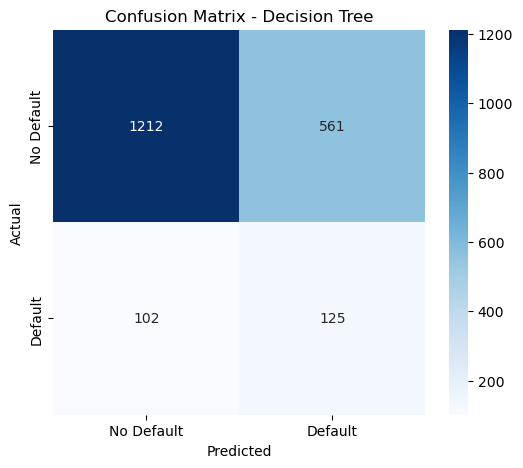

In [11]:
#Create confusion matrix
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Default', 'Default'],
            yticklabels=['No Default', 'Default'])
plt.title('Confusion Matrix - Decision Tree')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


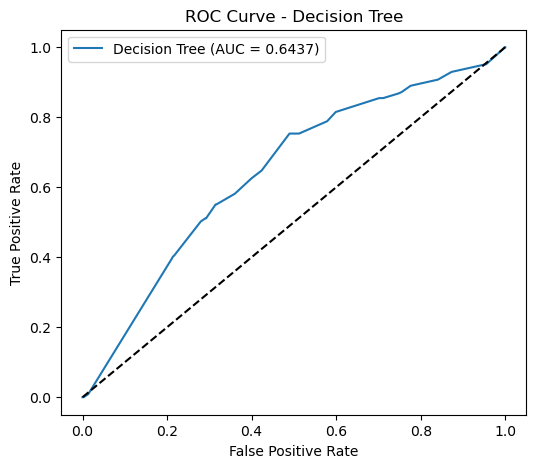

In [12]:
#Create ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_test_pred_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'Decision Tree (AUC = {test_roc_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curve - Decision Tree')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()


In [13]:
#Find feature importance
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': dt_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(importance_df.head(10))


                      Feature  Importance
0                         Age    0.314435
6                InterestRate    0.231478
5              NumCreditLines    0.184614
9                   Education    0.073400
1                      Income    0.067974
4              MonthsEmployed    0.046479
2                  LoanAmount    0.024792
15  EmploymentType_Unemployed    0.024420
3                 CreditScore    0.012127
19      LoanPurpose_Education    0.010030


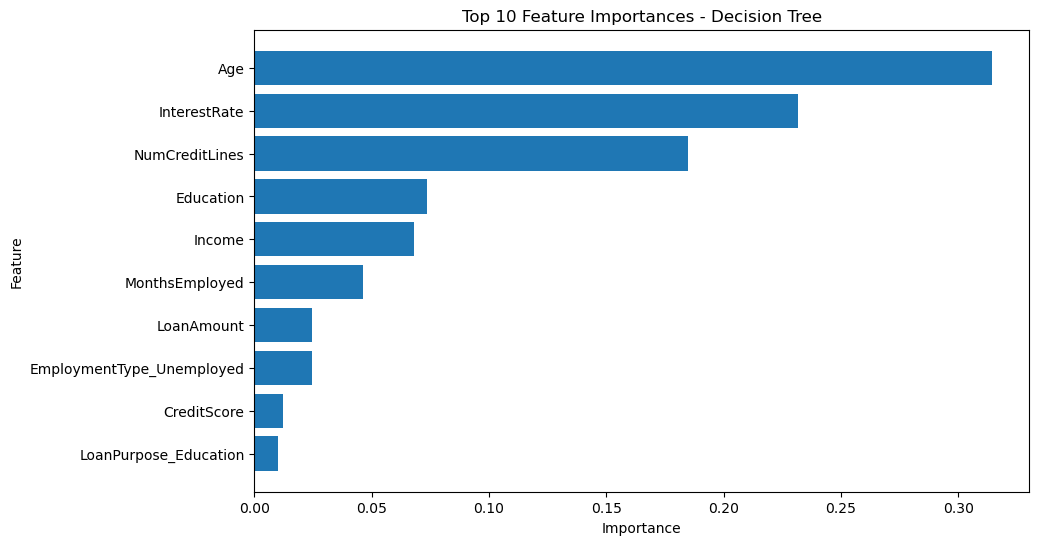

In [14]:
#Plot feature importance
top_features = importance_df.head(10).sort_values(by='Importance', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(top_features['Feature'], top_features['Importance'])
plt.title('Top 10 Feature Importances - Decision Tree')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()


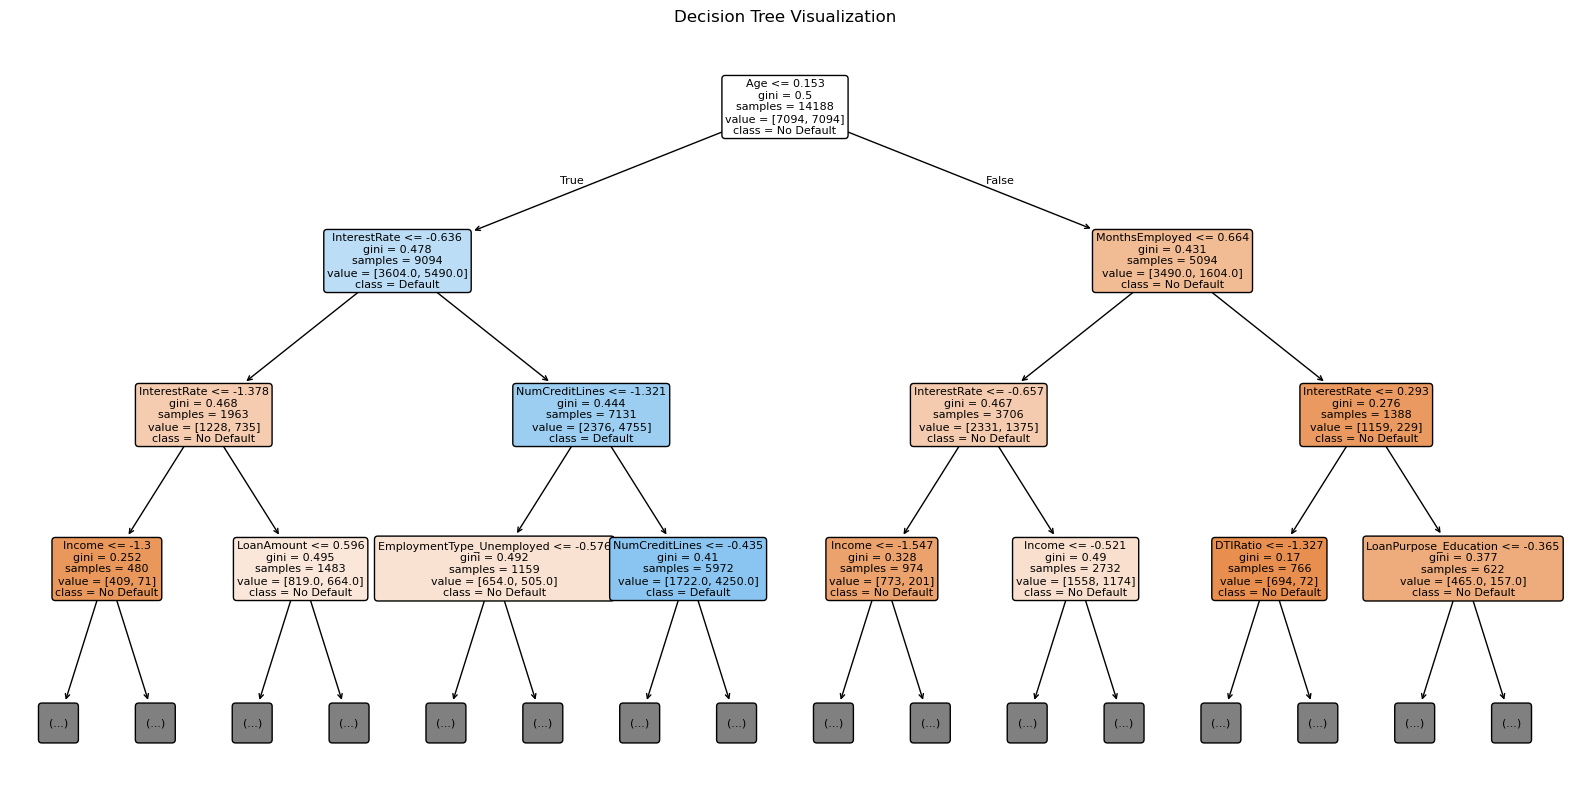

In [15]:
#Visualize the decision tree
plt.figure(figsize=(20, 10))
plot_tree(
    dt_model,
    feature_names=feature_names,
    class_names=['No Default', 'Default'],
    filled=True,
    rounded=True,
    fontsize=8,
    max_depth=3
)
plt.title("Decision Tree Visualization")
plt.show()


In [16]:
#Save the results in CSV file
results_summary = pd.DataFrame({
    'Model': ['Decision Tree'],
    'Train Accuracy': [train_accuracy],
    'Train Precision': [train_precision],
    'Train Recall': [train_recall],
    'Train F1': [train_f1],
    'Test Accuracy': [test_accuracy],
    'Test Precision': [test_precision],
    'Test Recall': [test_recall],
    'Test F1': [test_f1],
    'Test ROC-AUC': [test_roc_auc]
})

results_summary.to_csv('../results/decision_tree_results.csv', index=False)
print("Results saved successfully!")
results_summary


Results saved successfully!


,Model,Train Accuracy,Train Precision,Train Recall,Train F1,Test Accuracy,Test Precision,Test Recall,Test F1,Test ROC-AUC
0,Decision Tree,0.721455,0.71765,0.730195,0.723868,0.6685,0.182216,0.550661,0.273823,0.64367


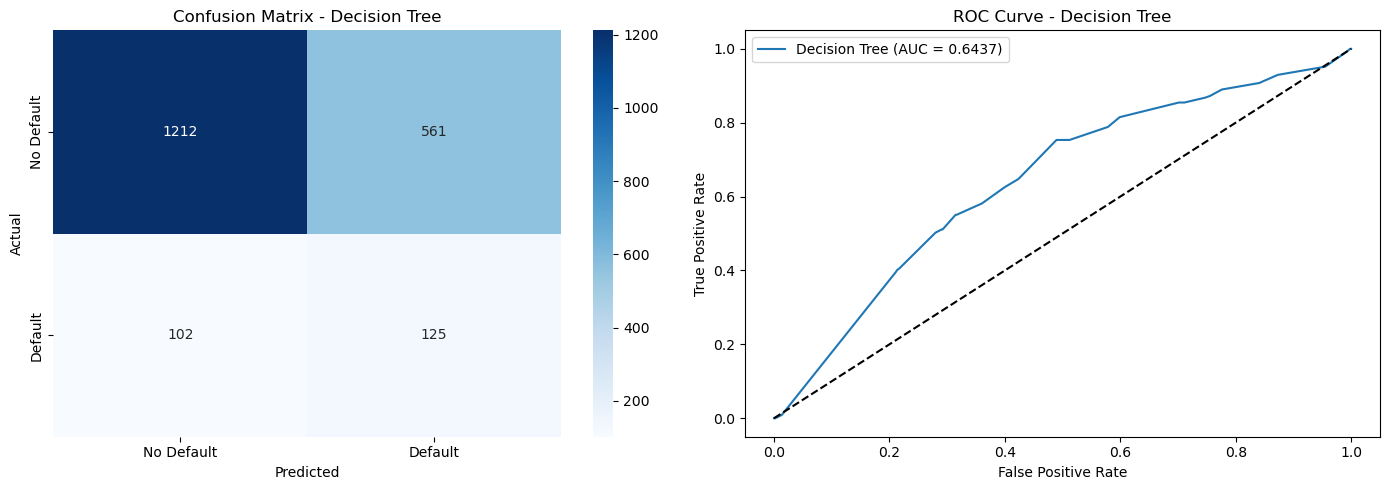

In [17]:
#Save confusion matrix and ROC curve image
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Default', 'Default'],
            yticklabels=['No Default', 'Default'],
            ax=axes[0])
axes[0].set_title('Confusion Matrix - Decision Tree')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# ROC Curve
axes[1].plot(fpr, tpr, label=f'Decision Tree (AUC = {test_roc_auc:.4f})')
axes[1].plot([0, 1], [0, 1], 'k--')
axes[1].set_title('ROC Curve - Decision Tree')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()

plt.tight_layout()
plt.savefig('../results/decision_tree_evaluation.png', dpi=300, bbox_inches='tight')
plt.show()


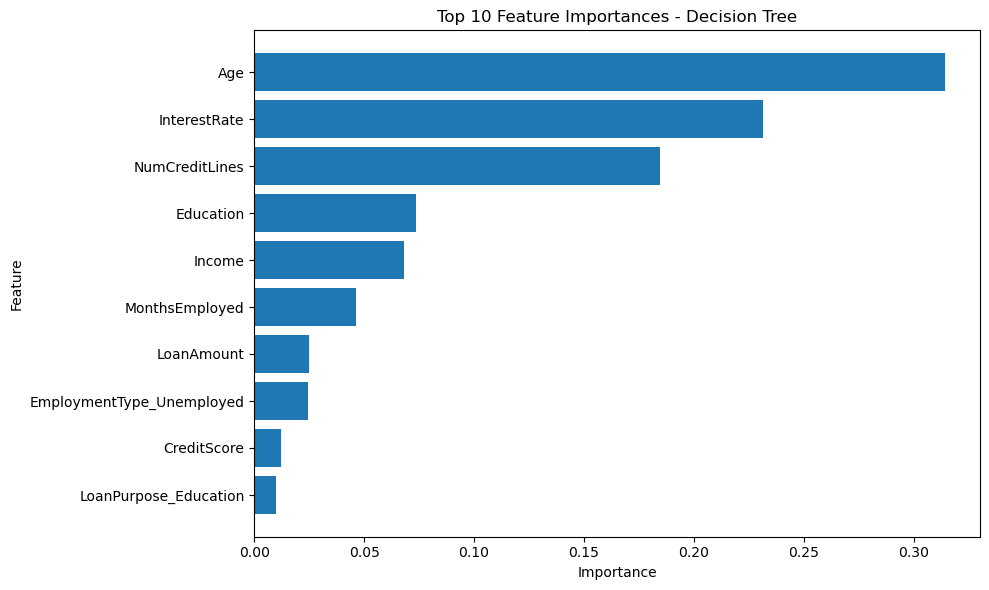

In [18]:
#Save feature importance plot
plt.figure(figsize=(10, 6))
plt.barh(top_features['Feature'], top_features['Importance'])
plt.title('Top 10 Feature Importances - Decision Tree')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig('../results/decision_tree_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()


In [19]:
#Save short text summary
with open('../results/decision_tree_summary.txt', 'w') as f:
    f.write("Decision Tree Model Summary\n")
    f.write("===========================\n\n")
    f.write(f"Train Accuracy: {train_accuracy:.4f}\n")
    f.write(f"Train Precision: {train_precision:.4f}\n")
    f.write(f"Train Recall: {train_recall:.4f}\n")
    f.write(f"Train F1-score: {train_f1:.4f}\n\n")
    f.write(f"Test Accuracy: {test_accuracy:.4f}\n")
    f.write(f"Test Precision: {test_precision:.4f}\n")
    f.write(f"Test Recall: {test_recall:.4f}\n")
    f.write(f"Test F1-score: {test_f1:.4f}\n")
    f.write(f"Test ROC-AUC: {test_roc_auc:.4f}\n\n")
    f.write("Top 10 Important Features:\n")
    for _, row in importance_df.head(10).iterrows():
        f.write(f"{row['Feature']} : {row['Importance']:.4f}\n")

print("Summary file saved!")




Summary file saved!
